# 02 · Cell-specific mechanics

**Panel:** p-Myosin IIa, α-Tubulin, ZO-1, E-cadherin, Fibronectin, LAMA4, Lamin A, Lamin B1

How cells are shaped, attached to each other and to the matrix, and how their nuclei are
built. Cytoskeleton (myosin, tubulin), junctions (ZO-1, E-cadherin), matrix (fibronectin,
laminin) and the nuclear lamina (Lamin A/B1).

This is the panel where **morphology features matter as much as intensities** — a cell
that changes shape has changed mechanically whether or not any marker moved.

The structure is the same as [chapter 01](01_signaling.ipynb); only the panel and the
biology change.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

from mcs2026 import analysis, panels, plotting
from mcs2026.config import H5AD_SLIM

plotting.set_style()
pd.set_option("display.width", 140)

THEME = "mechanics"

wells = pd.read_parquet(H5AD_SLIM.with_name("mcs2026_wells.parquet"))
cells = sc.read_h5ad(H5AD_SLIM.with_name("mcs2026_clean.h5ad"))
markers = analysis.panel_markers(THEME, wells.columns)
print(f"{len(markers)} markers: {', '.join(markers)}")

8 markers: p-MyosinIIa, a-Tubulin, ZO-1, E-cadherin, Fibronectin, LAMA4, LaminA, LaminB1


In [2]:
lookup = cells.var[cells.var.marker.isin(markers) & (cells.var.statistic == "mean_intensity")]
lookup[["marker", "round", "channel"]].sort_values("round").reset_index(drop=True)

,marker,round,channel
0,p-MyosinIIa,2,FITC
1,ZO-1,18,Cy5
2,a-Tubulin,19,FITC
3,E-cadherin,20,Cy5
4,Fibronectin,22,Cy5
5,LAMA4,24,Texas Red
6,LaminA,27,Cy5
7,LaminB1,27,Texas Red


## Effects per condition

In control-well standard deviations, against the DMSO wells of the same timepoint.
PMA is excluded throughout — [Step 16](../part3_analysis/1_preparation/03_normalisation.ipynb) showed it moves every marker by 4–11 SD, so
leaving it in would make every heatmap a picture of PMA.

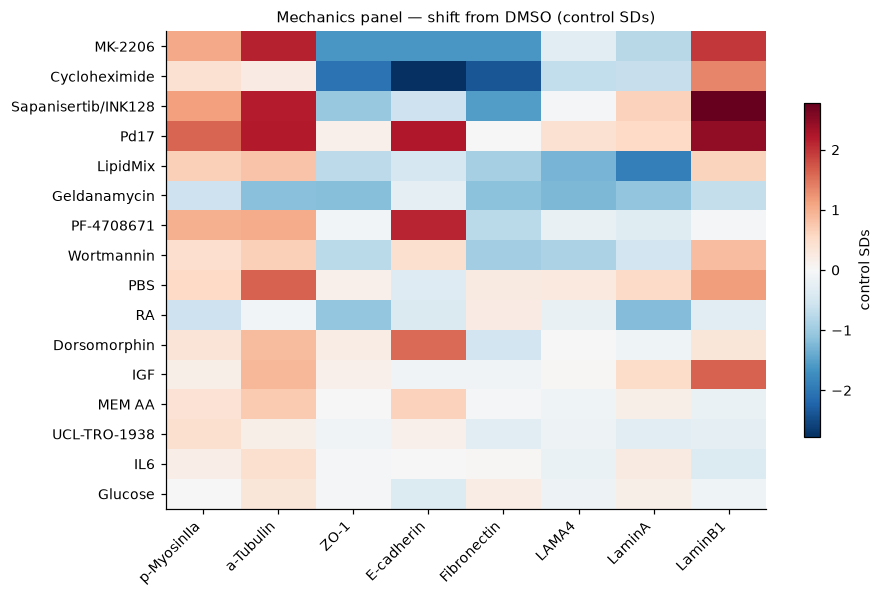

In [3]:
effects = analysis.effect_table(wells, markers, by_timepoint=False)
effects = effects.drop(index=analysis.OUTLIER_CONDITION, errors="ignore")
order = effects.abs().mean(axis=1).sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(8.5, 5.5))
matrix = effects.loc[order]
limit = np.nanpercentile(np.abs(matrix.values), 99)
im = ax.imshow(matrix.values, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
ax.set(yticks=range(len(order)), yticklabels=order)
ax.set_xticks(range(len(markers)))
ax.set_xticklabels(markers, rotation=45, ha="right")
ax.set_title(f"{THEME.capitalize()} panel — shift from DMSO (control SDs)")
fig.colorbar(im, ax=ax, shrink=0.7, label="control SDs")
fig.tight_layout()

## Ranked effects

In [4]:
ranked = analysis.rank_effects(wells, markers)
ranked.head(12).round(3)

,condition,marker,shift,n_wells,p,p_floor,abs_shift,at_p_floor
0,Sapanisertib/INK128,LaminB1,3.268,12,0.000,0.0,3.268,False
1,Cycloheximide,E-cadherin,-2.891,12,0.004,0.0,2.891,False
2,Pd17,LaminB1,2.464,12,0.000,0.0,2.464,False
3,Cycloheximide,Fibronectin,-2.374,12,0.001,0.0,2.374,False
4,Pd17,E-cadherin,2.216,12,0.001,0.0,2.216,False
5,Pd17,a-Tubulin,2.212,12,0.001,0.0,2.212,False
6,Sapanisertib/INK128,a-Tubulin,2.186,12,0.019,0.0,2.186,False
7,MK-2206,a-Tubulin,2.130,12,0.001,0.0,2.130,False
8,PF-4708671,E-cadherin,2.115,11,0.008,0.0,2.115,False
9,Cycloheximide,ZO-1,-2.051,12,0.000,0.0,2.051,False


### What the data says

**Cycloheximide strips the adhesion machinery.** E-cadherin falls 3.5 control SDs and
fibronectin 2.8. Cycloheximide blocks translation, so proteins disappear at a rate set
by their own turnover — and cell-surface adhesion proteins are replaced constantly.
This is a protein-half-life experiment that nobody designed as one.

**Lamin B1 rises under kinase inhibition** — with INK128 (+3.7), Pd17 (+2.7) and
MK-2206 (+2.7). Lamin B1 is very long-lived, so when growth slows and dilution by cell
division slows with it, lamin accumulates relative to everything else. The same logic,
running the other way, that makes E-cadherin fall.

Both results are about **turnover**, not about signaling — a useful reminder that an
intensity change is a change in *abundance*, and abundance is synthesis minus
degradation minus dilution by division.

## An embedding of this theme alone

variance explained: [0.352 0.299 0.128 0.064]


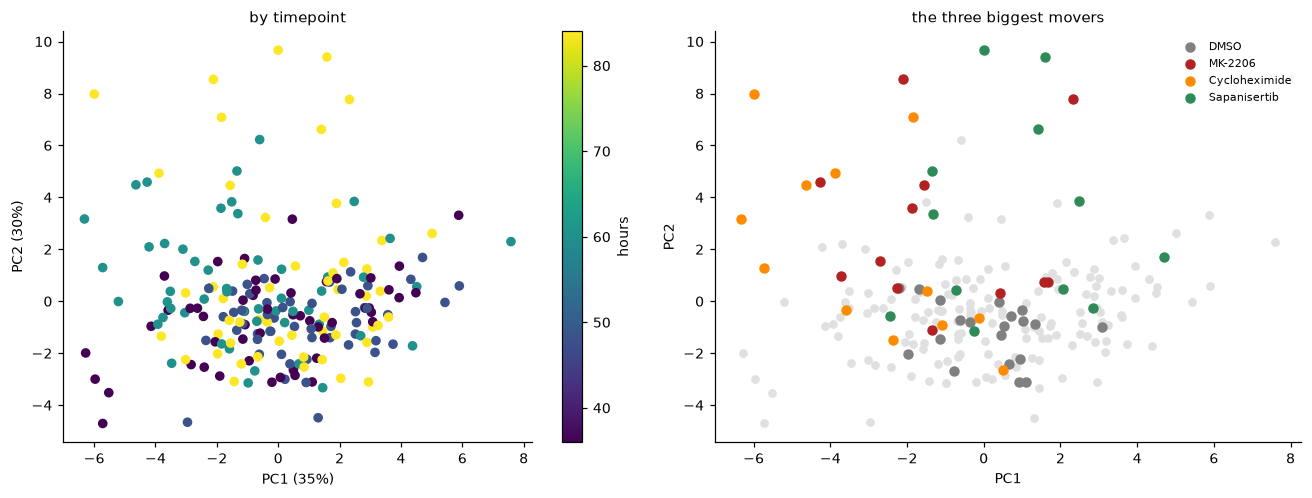

In [5]:
from sklearn.decomposition import PCA

usable = wells[wells.condition != analysis.OUTLIER_CONDITION]
matrix = usable[markers].fillna(0).values
pca = PCA(n_components=4, random_state=0).fit(matrix)
coords = pca.transform(matrix)
print("variance explained:", pca.explained_variance_ratio_[:4].round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
scatter = axes[0].scatter(coords[:, 0], coords[:, 1], c=usable.timepoint.values,
                          cmap="viridis", s=28)
axes[0].set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.0%})",
            ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.0%})", title="by timepoint")
fig.colorbar(scatter, ax=axes[0], label="hours")

top = list(effects.abs().mean(axis=1).sort_values(ascending=False).head(3).index)
axes[1].scatter(coords[:, 0], coords[:, 1], c="0.88", s=22)
for condition, colour in zip(["DMSO"] + top, ["0.5", "firebrick", "darkorange", "seagreen"]):
    mask = (usable.condition == condition).values
    axes[1].scatter(coords[mask, 0], coords[mask, 1], c=colour, s=34,
                    label=condition.split("/")[0][:22])
axes[1].set(xlabel="PC1", ylabel="PC2", title="the three biggest movers")
axes[1].legend(fontsize=7)
fig.tight_layout()

In [6]:
loadings = pd.DataFrame(pca.components_[:2].T, index=markers, columns=["PC1", "PC2"])
loadings.reindex(loadings.PC1.abs().sort_values(ascending=False).index).round(2)

,PC1,PC2
E-cadherin,0.58,-0.31
LaminA,0.44,0.01
ZO-1,0.37,-0.07
LAMA4,0.32,-0.01
Fibronectin,0.29,-0.41
LaminB1,0.26,0.63
a-Tubulin,0.26,0.51
p-MyosinIIa,0.10,0.25


## Single cells over time

The well means say the average moved. The single-cell distributions say whether every
cell moved a little or a subpopulation moved a lot.

strongest effect in this panel: Sapanisertib/INK128 on LaminB1 (+3.27 control SDs)


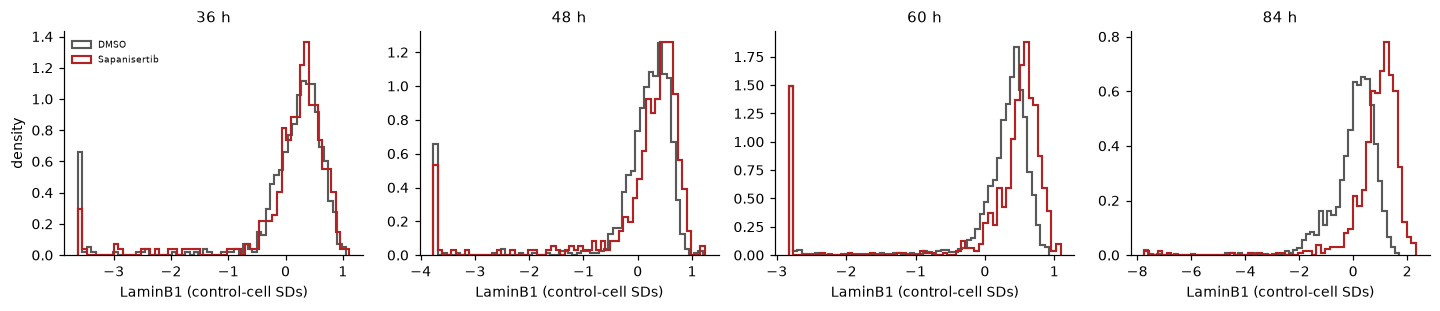

In [7]:
top_pair = ranked.iloc[0]
marker, condition = top_pair["marker"], top_pair["condition"]
print(f"strongest effect in this panel: {condition} on {marker} "
      f"({top_pair['shift']:+.2f} control SDs)")

column = cells.var.index[(cells.var.marker == marker)
                         & (cells.var.statistic == "mean_intensity")
                         & (cells.var.family == "Intensity")][0]
frame = pd.DataFrame({
    "value": np.asarray(cells[:, column].X).ravel(),
    "condition": cells.obs.condition.astype(str).values,
    "timepoint": cells.obs.timepoint_h.astype(int).values,
})

fig, axes = plotting.panel_grid(4, ncols=4, size=(3.3, 2.9))
for ax, timepoint in zip(axes, [36, 48, 60, 84]):
    block = frame[frame.timepoint == timepoint]
    for name, colour in [("DMSO", "0.35"), (condition, "firebrick")]:
        values = block.loc[block.condition == name, "value"]
        ax.hist(values, bins=60, histtype="step", density=True,
                color=colour, linewidth=1.4, label=name.split("/")[0][:18])
    ax.set(title=f"{timepoint} h", xlabel=f"{marker} (control-cell SDs)")
    if timepoint == 36:
        ax.set_ylabel("density")
        ax.legend(fontsize=6)
fig.tight_layout()

## One number for the theme

In [8]:
summary = analysis.theme_summary(wells, markers)
summary.drop(index=analysis.OUTLIER_CONDITION, errors="ignore").head(8).round(2)

condition
MK-2206                1.38
Cycloheximide          1.33
Sapanisertib/INK128    1.31
Pd17                   1.21
LipidMix               0.92
Geldanamycin           0.91
PF-4708671             0.70
Wortmannin             0.69
dtype: float32

In [9]:
summary.to_frame(THEME).to_parquet(H5AD_SLIM.with_name(f"theme_{THEME}.parquet"))
print(f"saved theme summary for {THEME}")

saved theme summary for mechanics


---

**Next:** [03 · Metabolism](03_metabolism.ipynb).